# **Lag features prediction with RF**

## Pre-procseeing lag_features

In [1]:
import numpy as np, pandas as pd
from feature_engine.timeseries.forecasting import LagFeatures

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Ope the preprocessed data
df = pd.read_csv('../data/cleaned_WHT_seeing_data.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,windspeed,airtemperature,relativehumidity,year,month,day,hour,minute,Seeing
0,12.919399,7.173338,35.522750,2020,1,31,19,10,-0.238520
1,13.455912,7.151790,36.587790,2020,1,31,19,20,0.030923
2,16.018960,7.253796,34.251087,2020,1,31,19,30,0.261599
3,15.579474,7.402426,33.061800,2020,1,31,19,40,0.308435
4,16.778657,7.355480,33.812690,2020,1,31,19,50,0.373899


In [3]:
# Creating timestamp
temp_cols = ['year', 'month', 'day', 'hour', 'minute']
df['timestamp'] = pd.to_datetime(df[temp_cols])

# Order by time and use timestamp as index
df_sorted = df.sort_values('timestamp').copy()
df_sorted.index = df_sorted['timestamp']

# Define nights as shifts: 17:00 (D) → 08:00 (D+1)
ts = df_sorted['timestamp']
hours = ts.dt.hour

# Nighttime mask: only 17:00–23:50 and 00:00–07:50
is_night = (hours >= 17) | (hours < 8)

# Base date at midnight of the calendar day
night_date = ts.dt.normalize()

# For times before 08:00, assign them to the previous calendar day
night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)

# Drop daytime rows and keep only real nights
night_date[~is_night] = pd.NaT

# Final night_id as a datetime (one per shift)
df_sorted['night_id'] = night_date

# Optionally, keep only nighttime rows going forward
df_sorted = df_sorted[is_night].copy()

df_sorted.head()

/tmp/ipykernel_10129/2217447232.py:20: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)
/tmp/ipykernel_10129/2217447232.py:20: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)
/tmp/ipykernel_10129/2217447232.py:23: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[~is_night] = pd.NaT
/tmp/ipykernel_10129/2217447232.py:23: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[~is_night] = pd.NaT


,windspeed,airtemperature,relativehumidity,year,month,day,hour,minute,Seeing,timestamp,night_id
timestamp,,,,,,,,,,,
2020-01-31 19:10:00,12.919399,7.173338,35.522750,2020,1,31,19,10,-0.238520,2020-01-31 19:10:00,2020-01-31
2020-01-31 19:20:00,13.455912,7.151790,36.587790,2020,1,31,19,20,0.030923,2020-01-31 19:20:00,2020-01-31
2020-01-31 19:30:00,16.018960,7.253796,34.251087,2020,1,31,19,30,0.261599,2020-01-31 19:30:00,2020-01-31
2020-01-31 19:40:00,15.579474,7.402426,33.061800,2020,1,31,19,40,0.308435,2020-01-31 19:40:00,2020-01-31
2020-01-31 19:50:00,16.778657,7.355480,33.812690,2020,1,31,19,50,0.373899,2020-01-31 19:50:00,2020-01-31


In [4]:
# Creating a function to convert minutes, hours, days, and months into sine and cosine functions to preserve
# their cyclic nature
def convert_temp_feat(data, feature, period):
    if feature == 'day':
        dt = pd.to_datetime(dict(
            year=data["year"],
            month=data["month"],
            day=data["day"],
            hour=data["hour"],
            minute=data["minute"],
        ), errors="coerce")

        # Annual seasonality (handles varying month lengths + leap years)
        doy = dt.dt.dayofyear
        year_len = 365.2425
        data["doy_sin"] = np.sin(2 * np.pi * (doy / year_len))
        data["doy_cos"] = np.cos(2 * np.pi * (doy / year_len))
        data.drop('day', axis=1, inplace=True)
    else:
        data[feature + '_sin'] = np.sin(2 * np.pi * data[feature] / period)
        data[feature + '_cos'] = np.cos(2 * np.pi * data[feature] / period)
        data.drop(feature, axis=1, inplace=True)
    return data

# Apply cyclic encodings for time-related features
df_sorted = convert_temp_feat(df_sorted, 'day', None)
df_sorted = convert_temp_feat(df_sorted, 'minute', 60)
df_sorted = convert_temp_feat(df_sorted, 'hour', 24)
df_sorted = convert_temp_feat(df_sorted, 'month', 12)

df_sorted.head()

,windspeed,airtemperature,relativehumidity,year,Seeing,timestamp,night_id,doy_sin,doy_cos,minute_sin,minute_cos,hour_sin,hour_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,,
2020-01-31 19:10:00,12.919399,7.173338,35.522750,2020,-0.238520,2020-01-31 19:10:00,2020-01-31,0.508366,0.861141,8.660254e-01,0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:20:00,13.455912,7.151790,36.587790,2020,0.030923,2020-01-31 19:20:00,2020-01-31,0.508366,0.861141,8.660254e-01,-0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:30:00,16.018960,7.253796,34.251087,2020,0.261599,2020-01-31 19:30:00,2020-01-31,0.508366,0.861141,5.665539e-16,-1.0,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:40:00,15.579474,7.402426,33.061800,2020,0.308435,2020-01-31 19:40:00,2020-01-31,0.508366,0.861141,-8.660254e-01,-0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:50:00,16.778657,7.355480,33.812690,2020,0.373899,2020-01-31 19:50:00,2020-01-31,0.508366,0.861141,-8.660254e-01,0.5,-0.965926,0.258819,0.5,0.866025


In [5]:
# Assigning features and target
# We'll keep the current meteorological + time features as baseline predictors
X_base = df_sorted.drop(columns=['Seeing'])
y = df_sorted['Seeing']

X_base.head()

,windspeed,airtemperature,relativehumidity,year,timestamp,night_id,doy_sin,doy_cos,minute_sin,minute_cos,hour_sin,hour_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,
2020-01-31 19:10:00,12.919399,7.173338,35.522750,2020,2020-01-31 19:10:00,2020-01-31,0.508366,0.861141,8.660254e-01,0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:20:00,13.455912,7.151790,36.587790,2020,2020-01-31 19:20:00,2020-01-31,0.508366,0.861141,8.660254e-01,-0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:30:00,16.018960,7.253796,34.251087,2020,2020-01-31 19:30:00,2020-01-31,0.508366,0.861141,5.665539e-16,-1.0,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:40:00,15.579474,7.402426,33.061800,2020,2020-01-31 19:40:00,2020-01-31,0.508366,0.861141,-8.660254e-01,-0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:50:00,16.778657,7.355480,33.812690,2020,2020-01-31 19:50:00,2020-01-31,0.508366,0.861141,-8.660254e-01,0.5,-0.965926,0.258819,0.5,0.866025


In [6]:
# Create lag features for seeing and meteorological variables
# We'll create lags of 1 to 30 minutes for Seeing, and 1 to 5 minutes for the exogenous variables.

lag_periods_seeing = list(range(1, 31))  # 30 minutes history
lag_periods_exog = list(range(1, 6))     # 5 minutes history

feature_cols_seeing = ['Seeing']
feature_cols_exog = ['windspeed', 'airtemperature', 'relativehumidity']

# Start from df_sorted, which already has night_id and time encodings
lagged_frames = []

for night, group in df_sorted.groupby('night_id'):
    g = group.copy().sort_index()

    # Seeing lags
    for p in lag_periods_seeing:
        g[f'Seeing_lag_{p}'] = g['Seeing'].shift(p)

    # Exogenous lags
    for col in feature_cols_exog:
        for p in lag_periods_exog:
            g[f'{col}_lag_{p}'] = g[col].shift(p)

    lagged_frames.append(g)

# Concatenate all nights back together
df_lagged = pd.concat(lagged_frames).sort_index()

# Drop rows with any NaN in lagged columns (these correspond to the first few minutes of each night)
lagged_cols = [c for c in df_lagged.columns if 'lag_' in c]
df_lagged = df_lagged.dropna(subset=lagged_cols)

df_lagged.head()

,windspeed,airtemperature,relativehumidity,year,Seeing,timestamp,night_id,doy_sin,doy_cos,minute_sin,...,airtemperature_lag_1,airtemperature_lag_2,airtemperature_lag_3,airtemperature_lag_4,airtemperature_lag_5,relativehumidity_lag_1,relativehumidity_lag_2,relativehumidity_lag_3,relativehumidity_lag_4,relativehumidity_lag_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-02-01 01:00:00,10.689804,7.246534,30.414680,2020,0.824255,2020-02-01 01:00:00,2020-01-31,0.523104,0.852269,0.000000e+00,...,7.249352,7.187391,7.139959,7.200382,7.208083,30.868431,33.161250,33.401920,33.862430,33.428420
2020-02-01 01:10:00,13.172379,7.410473,29.025800,2020,0.746097,2020-02-01 01:10:00,2020-01-31,0.523104,0.852269,8.660254e-01,...,7.246534,7.249352,7.187391,7.139959,7.200382,30.414680,30.868431,33.161250,33.401920,33.862430
2020-02-01 01:20:00,14.339338,7.549146,28.106750,2020,0.753146,2020-02-01 01:20:00,2020-01-31,0.523104,0.852269,8.660254e-01,...,7.410473,7.246534,7.249352,7.187391,7.139959,29.025800,30.414680,30.868431,33.161250,33.401920
2020-02-01 01:30:00,15.414652,7.755991,26.978788,2020,0.684081,2020-02-01 01:30:00,2020-01-31,0.523104,0.852269,5.665539e-16,...,7.549146,7.410473,7.246534,7.249352,7.187391,28.106750,29.025800,30.414680,30.868431,33.161250
2020-02-01 01:40:00,14.025007,7.745506,27.120860,2020,0.702850,2020-02-01 01:40:00,2020-01-31,0.523104,0.852269,-8.660254e-01,...,7.755991,7.549146,7.410473,7.246534,7.249352,26.978788,28.106750,29.025800,30.414680,30.868431


In [7]:
# Define final feature matrix X and target y after lagging
# Drop non-numeric / identifier columns that the RF should not try to model directly
X = df_lagged.drop(columns=['Seeing', 'timestamp', 'night_id'])
y = df_lagged['Seeing']

In [8]:
df_lagged[['Seeing'] + [c for c in df_lagged.columns if 'Seeing_lag_' in c]].head()

,Seeing,Seeing_lag_1,Seeing_lag_2,Seeing_lag_3,Seeing_lag_4,Seeing_lag_5,Seeing_lag_6,Seeing_lag_7,Seeing_lag_8,Seeing_lag_9,...,Seeing_lag_21,Seeing_lag_22,Seeing_lag_23,Seeing_lag_24,Seeing_lag_25,Seeing_lag_26,Seeing_lag_27,Seeing_lag_28,Seeing_lag_29,Seeing_lag_30
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-02-01 01:00:00,0.824255,0.834538,0.482673,0.729337,0.753196,0.641814,0.489966,0.500404,0.588652,0.598746,...,0.113140,0.197399,0.334487,0.312322,0.328088,0.373899,0.308435,0.261599,0.030923,-0.238520
2020-02-01 01:10:00,0.746097,0.824255,0.834538,0.482673,0.729337,0.753196,0.641814,0.489966,0.500404,0.588652,...,0.226775,0.113140,0.197399,0.334487,0.312322,0.328088,0.373899,0.308435,0.261599,0.030923
2020-02-01 01:20:00,0.753146,0.746097,0.824255,0.834538,0.482673,0.729337,0.753196,0.641814,0.489966,0.500404,...,0.324315,0.226775,0.113140,0.197399,0.334487,0.312322,0.328088,0.373899,0.308435,0.261599
2020-02-01 01:30:00,0.684081,0.753146,0.746097,0.824255,0.834538,0.482673,0.729337,0.753196,0.641814,0.489966,...,0.393944,0.324315,0.226775,0.113140,0.197399,0.334487,0.312322,0.328088,0.373899,0.308435
2020-02-01 01:40:00,0.702850,0.684081,0.753146,0.746097,0.824255,0.834538,0.482673,0.729337,0.753196,0.641814,...,0.299159,0.393944,0.324315,0.226775,0.113140,0.197399,0.334487,0.312322,0.328088,0.373899


In [9]:
# Split train/validation/test by night_id (no leakage between nights)

# Get unique nights in chronological order
unique_nights = df_lagged['night_id'].sort_values().unique()

n_nights = len(unique_nights)
train_end = int(0.7 * n_nights)
val_end = int(0.85 * n_nights)

train_nights = unique_nights[:train_end]
val_nights = unique_nights[train_end:val_end]
test_nights = unique_nights[val_end:]

train_mask = df_lagged['night_id'].isin(train_nights)
val_mask = df_lagged['night_id'].isin(val_nights)
test_mask = df_lagged['night_id'].isin(test_nights)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

X_train.shape, X_val.shape, X_test.shape

((8840, 57), (1763, 57), (2072, 57))

## Training RandomForest Regressor

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

# Baseline Random Forest
rf = RandomForestRegressor(
    n_estimators=300,       
    max_depth=None,           # or even 10–15 if performance holds
    min_samples_leaf=1,     # prevents extremely deep/sparse leaves
    max_features=0.5,    # or 0.3–0.5 to reduce split cost
    max_samples=0.7,        # use 70% of samples per tree (if sklearn >= 0.22)
    bootstrap=True,
    n_jobs=4,               # lower parallelism to reduce RAM peaks
    random_state=0
)

rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)

rmse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

np.sqrt(rmse_val), mae_val, r2_val

(0.13635080602044095, 0.1007957915713413, 0.8819494766051794)

In [11]:
# Hyperparameter tuning with group-aware cross-validation using night_id as group

param_distributions = {
    'n_estimators': [300],
    'max_depth': [None],
    'min_samples_leaf': [1],
    'max_features': [0.5],
}

# Use only train+val for tuning, but keep track of groups by night_id
tune_mask = train_mask | val_mask
X_tune = X[tune_mask]
y_tune = y[tune_mask]

# Groups for GroupKFold: night_id as group label
groups = df_lagged.loc[tune_mask, 'night_id']

gkf = GroupKFold(n_splits=5)

rf_base = RandomForestRegressor(n_jobs=4, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=20,
    cv=gkf.split(X_tune, y_tune, groups=groups),
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=4,
    random_state=42,
)

random_search.fit(X_tune, y_tune)

best_rf = random_search.best_estimator_
random_search.best_params_, random_search.best_score_

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


({'n_estimators': 300,
  'min_samples_leaf': 1,
  'max_features': 0.5,
  'max_depth': None},
 -0.15457126550483655)

In [12]:
# Refit best model on full train+val, then evaluate on test

best_rf.fit(X_tune, y_tune)

y_test_pred = best_rf.predict(X_test)

rmse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

np.sqrt(rmse_test), mae_test, r2_test

(0.159598615084427, 0.11829229721339138, 0.826604796624193)

In [13]:
import matplotlib.pyplot as plt

# Add predictions back to a copy of df_lagged for analysis
results = df_lagged.copy()
results = results.loc[test_mask].copy()
results['y_true'] = y_test
results['y_pred'] = y_test_pred

# Overall metrics (already computed above): rmse_test, mae_test, r2_test
print(f"Test RMSE: {rmse_test:.3f}")
print(f"Test MAE: {mae_test:.3f}")
print(f"Test R^2:  {r2_test:.3f}")

# Per-night metrics
night_metrics = []
for night, group in results.groupby('night_id'):
    rmse_n = np.sqrt(mean_squared_error(group['y_true'], group['y_pred']))
    mae_n = mean_absolute_error(group['y_true'], group['y_pred'])
    r2_n = r2_score(group['y_true'], group['y_pred'])
    night_metrics.append({'night_id': night, 'rmse': rmse_n, 'mae': mae_n, 'r2': r2_n})

night_metrics_df = pd.DataFrame(night_metrics).sort_values('night_id')
night_metrics_df.head(10)

Test RMSE: 0.025
Test MAE: 0.118
Test R^2:  0.827


/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


,night_id,rmse,mae,r2
0,2023-08-20,0.111848,0.086266,0.808211
1,2023-08-21,0.145529,0.106006,-0.619531
2,2023-08-23,0.067364,0.057816,0.356692
3,2023-08-26,0.204409,0.168759,0.624418
4,2023-08-27,0.168669,0.142057,-5.259632
5,2023-08-29,0.081104,0.062450,0.307708
6,2023-09-04,0.209139,0.159700,-0.326359
7,2023-09-06,0.173997,0.150323,0.094063
8,2023-09-07,0.165451,0.127028,0.163886
9,2023-09-08,0.140823,0.115398,0.321092


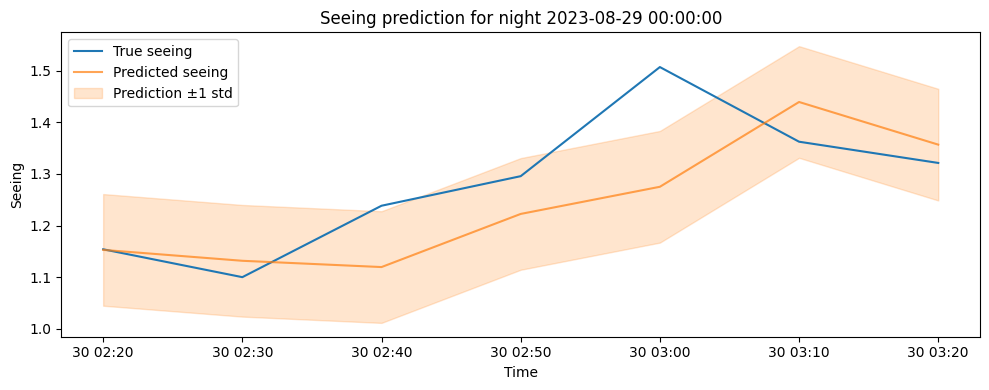

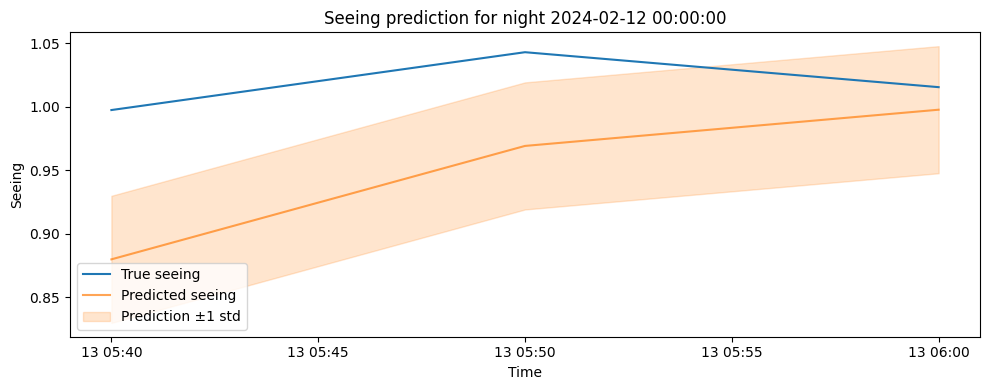

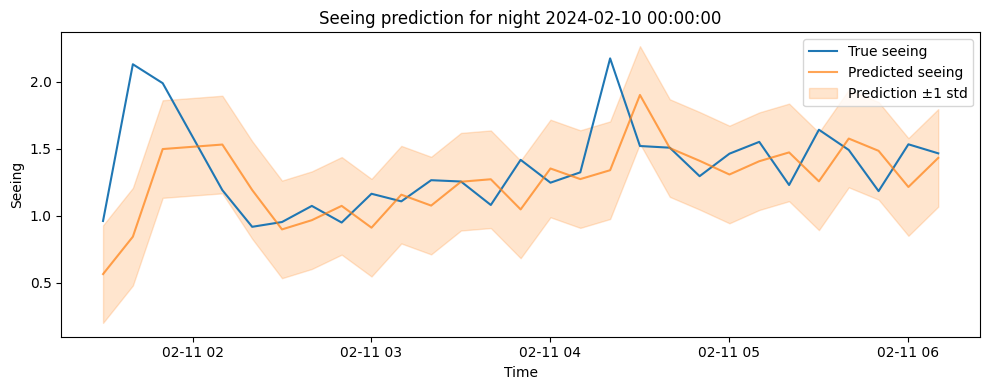

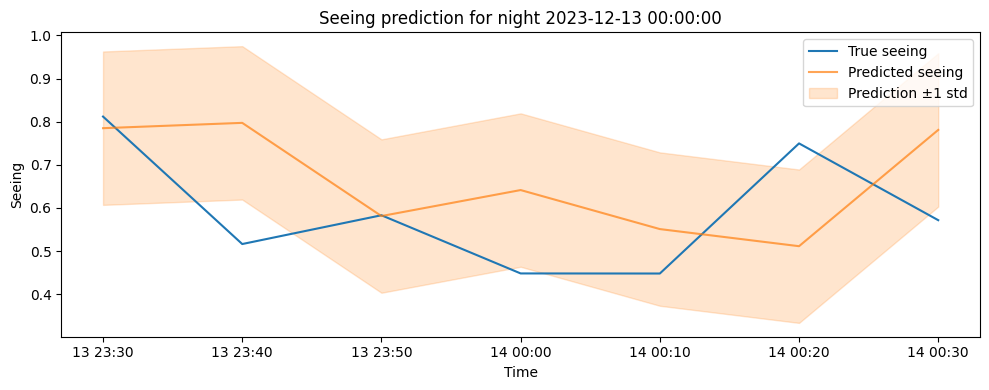

In [23]:
example_nights = night_metrics_df.sort_values('rmse')[4:6]['night_id'].tolist() + \
                 night_metrics_df.sort_values('rmse')[-4:-2]['night_id'].tolist()
example_nights = list(dict.fromkeys(example_nights))  # unique while preserving order

for night in example_nights:
    g = results[results['night_id'] == night].copy()

    # Work in original seeing units
    y_true = np.exp(g['y_true'])
    y_pred = np.exp(g['y_pred'])

    # Residuals in original units
    residuals = y_true - y_pred
    err_std = residuals.std()
    q25, q75 = np.percentile(residuals, [25, 75])

    plt.figure(figsize=(10, 4))

    # True and predicted
    plt.plot(g.index, y_true, label='True seeing')
    plt.plot(g.index, y_pred, label='Predicted seeing', alpha=0.7)

    # ±1 standard deviation band around prediction
    plt.fill_between(
        g.index,
        y_pred - err_std,
        y_pred + err_std,
        color='C1',
        alpha=0.2,
        label='Prediction ±1 std'
    )

    plt.title(f'Seeing prediction for night {night}')
    plt.xlabel('Time')
    plt.ylabel('Seeing')
    plt.legend()
    plt.tight_layout()
    plt.show()

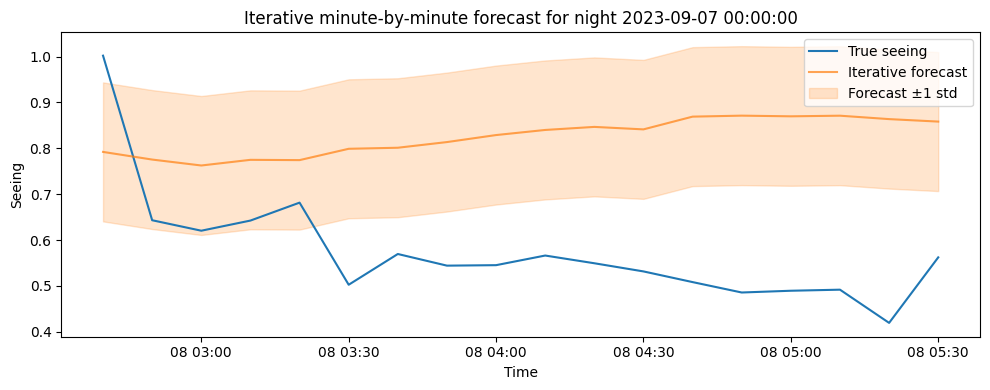

In [22]:
plt.figure(figsize=(10, 4))

y_true_iter = np.exp(night_data['Seeing'])
y_pred_iter = np.exp(iterative_preds)

residuals_iter = y_true_iter - y_pred_iter
err_std_iter = residuals_iter.std()
q25_iter, q75_iter = np.percentile(residuals_iter, [25, 75])

plt.plot(night_data.index, y_true_iter, label='True seeing')
plt.plot(night_data.index, y_pred_iter, label='Iterative forecast', alpha=0.7)

# ±1 std band
plt.fill_between(
    night_data.index,
    y_pred_iter - err_std_iter,
    y_pred_iter + err_std_iter,
    color='C1',
    alpha=0.2,
    label='Forecast ±1 std'
)

plt.title(f'Iterative minute-by-minute forecast for night {sample_night}')
plt.xlabel('Time')
plt.ylabel('Seeing')
plt.legend()
plt.tight_layout()
plt.show()